# Bactomata // Plate Generator

In [34]:
import sys, os, random, time, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import random

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

In [35]:
from google.colab import drive
drive.mount('/content/drive')

dirName='/content/drive/Shareddrives/ESB_Code/Bactomata/'
PROJECT_ROOT = Path(dirName)

os.chdir(PROJECT_ROOT)
print('Current directory:', Path.cwd())

pathOT='./bactomata/'
sys.path.append(pathOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/drive/Shareddrives/ESB_Code/Bactomata


In [36]:
import importlib
import bactomata.layout_widgets as blw

importlib.reload(blw)

<module 'bactomata.layout_widgets' from '/content/drive/Shareddrives/ESB_Code/Bactomata/bactomata/layout_widgets.py'>

## User-defined parameters

In [37]:

expeID='Bactomata_Example'

sample_vol=20
max_vol=200

num_cols=12
num_rows=8


In [38]:
num_plates = 2
same_media_layout_all_plates = False
same_bacteria_layout_all_plates = False

# Define Experiment Layouts


In [39]:
# Main experiment folder
EXPERIMENT_DIR = Path("experiments") / expeID

# Subfolders
LAYOUT_DIR = EXPERIMENT_DIR / "raw" / "layouts"
OT_SCRIPT_DIR = EXPERIMENT_DIR / "OT_scripts"

# Create folders if they do not exist
LAYOUT_DIR.mkdir(parents=True, exist_ok=True)
OT_SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

# File names
scriptFile = f"{expeID}_script.py"

# Layout files
fileLayoutName = LAYOUT_DIR / f"{expeID}_media_layout.txt"
fileInoculationName = LAYOUT_DIR / f"{expeID}_bacteria_layout.txt"
fileTroughName = LAYOUT_DIR / f"{expeID}_trough_layout.txt"

# Key dictionaries
fileMediaKeyDictName = LAYOUT_DIR / f"{expeID}_media_key_dict.txt"
fileBacteriaKeyDictName = LAYOUT_DIR / f"{expeID}_bacteria_key_dict.txt"

# Legacy name used by OTScriptGenerator/DataLoader.
# For now, this points to the media key dictionary.
fileDictName = fileMediaKeyDictName

# Outfile: robot instructions
fileRobotName = OT_SCRIPT_DIR / scriptFile


In [40]:
params = blw.getParams(
    fileLayoutName=str(fileLayoutName),
    fileDictName=str(fileDictName),  # legacy: media key dictionary
    fileTroughName=str(fileTroughName),
    fileInoculationName=str(fileInoculationName),  # legacy name: bacteria layout
    fileRobotName=str(fileRobotName),
    max_vol=max_vol,
    num_rows=num_rows,
    num_cols=num_cols,
    num_plates=num_plates,
    sample_vol=sample_vol,
)

# New explicit paths used by Bactomata.
params["fileMediaKeyDictName"] = str(fileMediaKeyDictName)
params["fileBacteriaKeyDictName"] = str(fileBacteriaKeyDictName)


In [41]:
print("Media layout:        ", params["fileLayoutName"])
print("Bacteria layout:     ", params["fileInoculationName"])
print("Trough layout:       ", params["fileTroughName"])
print("Media key dict:      ", params["fileMediaKeyDictName"])
print("Bacteria key dict:   ", params["fileBacteriaKeyDictName"])
print("Legacy fileDictName: ", params["fileDictName"])
print("OT script:           ", params["fileRobotName"])


Media layout:         experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_layout.txt
Bacteria layout:      experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_layout.txt
Trough layout:        experiments/Bactomata_Example/raw/layouts/Bactomata_Example_trough_layout.txt
Media key dict:       experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt
Bacteria key dict:    experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_key_dict.txt
Legacy fileDictName:  experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt
OT script:            experiments/Bactomata_Example/OT_scripts/Bactomata_Example_script.py


### Trough Layout

In [42]:
trough_layout_inputs = blw.setup_trough_layout_inputs(
    params,
    nrows=3,
    ncols=4,
)

HTML(value='<b>Trough layout</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [43]:
trough_layout_string, trough_unique_keys, trough_layout = blw.save_and_load_trough_layout(
    params,
    trough_layout_inputs,
)

### Plate Layout

In [44]:
def load_multiplate_layout_from_file(file_path, num_rows=8, num_cols=12, separator="<br>"):
    """
    Load one or more plate-layout matrices from a text file.

    Plates are separated by a line containing <br>.
    """

    with open(file_path, "r") as file:
        content = file.read().strip()

    if not content:
        return []

    plate_blocks = [block.strip() for block in content.split(separator)]

    plate_layouts = []

    for block in plate_blocks:
        rows = []

        for line in block.splitlines():
            line = line.strip()
            if line:
                rows.append(line.split())

        if rows:
            plate_layouts.append(rows)

    return plate_layouts

In [45]:
def save_multiplate_layout_to_file(plate_layouts, file_path, separator="<br>"):
    """
    Save one or more plate-layout matrices to a single text file.

    Plates are separated by a line containing <br>.
    """

    plate_strings = []

    for layout in plate_layouts:
        layout_string = "\n".join(
            " ".join(str(value) for value in row)
            for row in layout
        )
        plate_strings.append(layout_string)

    output_string = f"\n{separator}\n".join(plate_strings)

    with open(file_path, "w") as file:
        file.write(output_string + "\n")

In [46]:
def get_matrix_data(matrix_inputs):
    """
    Extract a matrix from create_matrix_input() widgets.
    """

    M = []

    for row in matrix_inputs:
        row_values = []

        for widget in row:
            value = widget.value.strip()

            if value == "":
                value = "0"

            row_values.append(value)

        M.append(row_values)

    return M

In [47]:
def setup_multiplate_layout_inputs(
    params,
    layout_file_key,
    num_plates=1,
    same_layout_all_plates=True,
    nrows=8,
    ncols=12,
    title="Media layout",
):
    """
    Create layout input widgets for one or more plates.

    Parameters
    ----------
    params : dict
        Parameter dictionary.

    layout_file_key : str
        Key in params pointing to the layout file.
        Example: "fileLayoutName" or "fileInoculationName".

    num_plates : int
        Number of plates.

    same_layout_all_plates : bool
        If True, create one widget and reuse it for all plates.
        If False, create one widget per plate.

    nrows, ncols : int
        Plate dimensions.

    title : str
        Title shown above widgets.

    Returns
    -------
    layout_inputs : list
        If same_layout_all_plates=True, a list with one widget matrix.
        If False, a list with one widget matrix per plate.
    """

    file_path = params[layout_file_key]

    if os.path.exists(file_path):
        predefined_layouts = load_multiplate_layout_from_file(
            file_path,
            num_rows=nrows,
            num_cols=ncols,
        )
    else:
        predefined_layouts = []

    layout_inputs = []

    if same_layout_all_plates:
        if len(predefined_layouts) > 0:
            default_matrix = predefined_layouts[0]
        else:
            default_matrix = None

        matrix_inputs = blw.create_matrix_input(
            default_matrix=default_matrix,
            nrows=nrows,
            ncols=ncols,
            title=f"{title} | shared across {num_plates} plate(s)",
        )

        layout_inputs.append(matrix_inputs)

    else:
        for plate_idx in range(num_plates):
            if plate_idx < len(predefined_layouts):
                default_matrix = predefined_layouts[plate_idx]
            else:
                default_matrix = None

            matrix_inputs = blw.create_matrix_input(
                default_matrix=default_matrix,
                nrows=nrows,
                ncols=ncols,
                title=f"{title} | plate {plate_idx + 1}",
            )

            layout_inputs.append(matrix_inputs)

    return layout_inputs

In [48]:
def save_multiplate_layout_from_inputs(
    layout_inputs,
    file_path,
    num_plates=1,
    same_layout_all_plates=True,
    separator="<br>",
):
    """
    Extract one or more plate layouts from widgets and save them to file.
    """

    if same_layout_all_plates:
        shared_layout = get_matrix_data(layout_inputs[0])
        plate_layouts = [shared_layout for _ in range(num_plates)]
    else:
        plate_layouts = [
            get_matrix_data(inputs)
            for inputs in layout_inputs
        ]

    save_multiplate_layout_to_file(
        plate_layouts,
        file_path,
        separator=separator,
    )

    return plate_layouts

In [49]:
media_layout_inputs = setup_multiplate_layout_inputs(
    params=params,
    layout_file_key="fileLayoutName",
    num_plates=num_plates,
    same_layout_all_plates=same_media_layout_all_plates,
    nrows=8,
    ncols=12,
    title="Media layout",
)

HTML(value='<b>Media layout | plate 1</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

HTML(value='<b>Media layout | plate 2</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [67]:
M_all = save_multiplate_layout_from_inputs(
    layout_inputs=media_layout_inputs,
    file_path=params["fileLayoutName"],
    num_plates=num_plates,
    same_layout_all_plates=same_media_layout_all_plates,
)

In [68]:
M_all[0]

[['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0']]

In [69]:
M_all[1]

[['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2']]

### Media Key Dictionary


In [70]:
def get_unique_keys_from_multiplate_layouts(layouts, empty_key="0"):
    """
    Return sorted unique non-empty keys from multiplate layouts.

    Expected structure:
        layouts[plate][row][column]
    """

    unique_keys = set()

    for plate_layout in layouts:
        for row in plate_layout:
            for item in row:
                if item != empty_key:
                    unique_keys.add(item)

    return sorted(unique_keys)

In [71]:
def setup_key_dict_inputs(
    layouts,
    source_keys,
    key_dict_file,
):
    """
    Create key-dictionary input widgets for the keys present in multiplate layouts.

    Expected layout structure:
        layouts[plate][row][column]
    """

    layout_unique_keys = get_unique_keys_from_multiplate_layouts(layouts)

    if os.path.exists(key_dict_file):
        predefined_key_data = blw.load_key_data(key_dict_file)

        key_input_widgets = blw.create_input_fields_for_keys(
            unique_keys=layout_unique_keys,
            predefined_data=predefined_key_data,
            source_keys=source_keys,
        )

    else:
        key_input_widgets = blw.create_input_fields_for_keys(
            unique_keys=layout_unique_keys,
            predefined_data=None,
            source_keys=source_keys,
        )

    return layout_unique_keys, key_input_widgets

In [72]:
media_source_keys = sorted(trough_unique_keys)

print("Media source keys:", media_source_keys)

M_unique_keys, media_key_input_widgets = setup_key_dict_inputs(
    layouts=M_all,
    source_keys=media_source_keys,
    key_dict_file=params["fileMediaKeyDictName"],
)

Media source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']


In [73]:
media_key_data = blw.save_key_dict_from_widgets(
    media_key_input_widgets,
    params["fileMediaKeyDictName"],
    source_keys=media_source_keys,
)

[{'KEY': 'M0', 'AMP': 0, 'CHL': 0, 'LB': 200, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'M1', 'AMP': 0, 'CHL': 100, 'LB': 100, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'M2', 'AMP': 100, 'CHL': 0, 'LB': 100, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}]

> Exporting experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt


In [74]:
media_dict = blw.load_key_dict_from_file(
    params["fileMediaKeyDictName"]
)

media_cmap, media_source_keys, media_source_colors = blw.build_media_cmap(
    media_dict,
    empty_color="lightgray",
    cmap_name="tab10",
)

print("Media source keys:", media_source_keys)
print("Media source colors:", media_source_colors)
print("Media cmap:", media_cmap)

Media source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']
Media source colors: {'AMP': (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), 'CHL': (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)), 'LB': (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0)), 'OV1': (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0)), 'OV2': (np.float64(0.5803921568627451), np.float64(0.403921568627451), np.float64(0.7411764705882353), np.float64(1.0)), 'OV3': (np.float64(0.5490196078431373), np.float64(0.33725490196078434), np.float64(0.29411764705882354), np.float64(1.0)), 'OV4': (np.float64(0.8901960784313725), np.float64(0.4666666666666667), np.float64(0.7607843137254902), np.float64(1.0))}
Media cmap: {'M0': (0.1725490196078432, 0.6274509803921569, 0.172

In [75]:
def plotHeatmapsFromLayouts(
    params,
    layouts,
    color_map,
    title="Layout",
):
    """
    Plot one or more plate-layout heatmaps.

    Parameters
    ----------
    params : dict
        Bactomata parameter dictionary.

    layouts : list
        Either a single layout matrix or a list of layout matrices.

    color_map : dict
        Dictionary mapping layout keys to colors.

    title : str
        Base title for the plots.
    """

    # If user passed a single matrix, wrap it as a list
    if len(layouts) > 0 and isinstance(layouts[0][0], str):
        layouts = [layouts]

    for plate_idx, layout in enumerate(layouts):
        print(f"\n\n**** {title.upper()} | PLATE {plate_idx + 1}:\n")

        blw.plotHeatmapFromLayout(
            params,
            layout,
            color_map,
        )



**** MEDIA LAYOUT | PLATE 1:



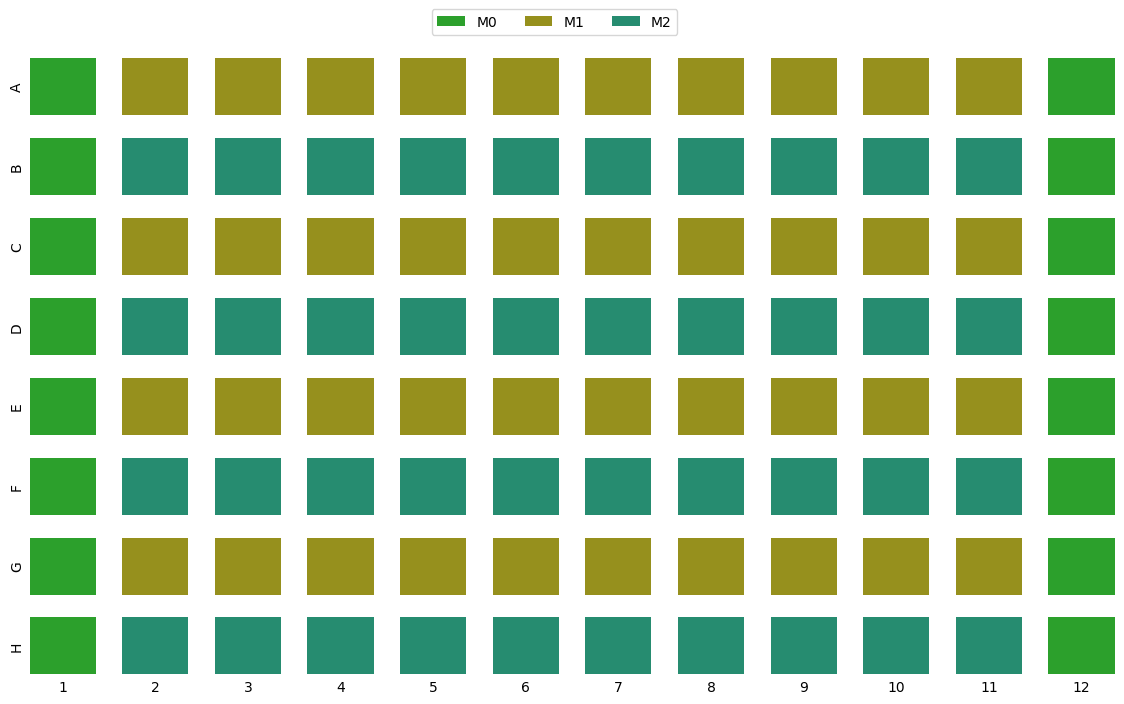



**** MEDIA LAYOUT | PLATE 2:



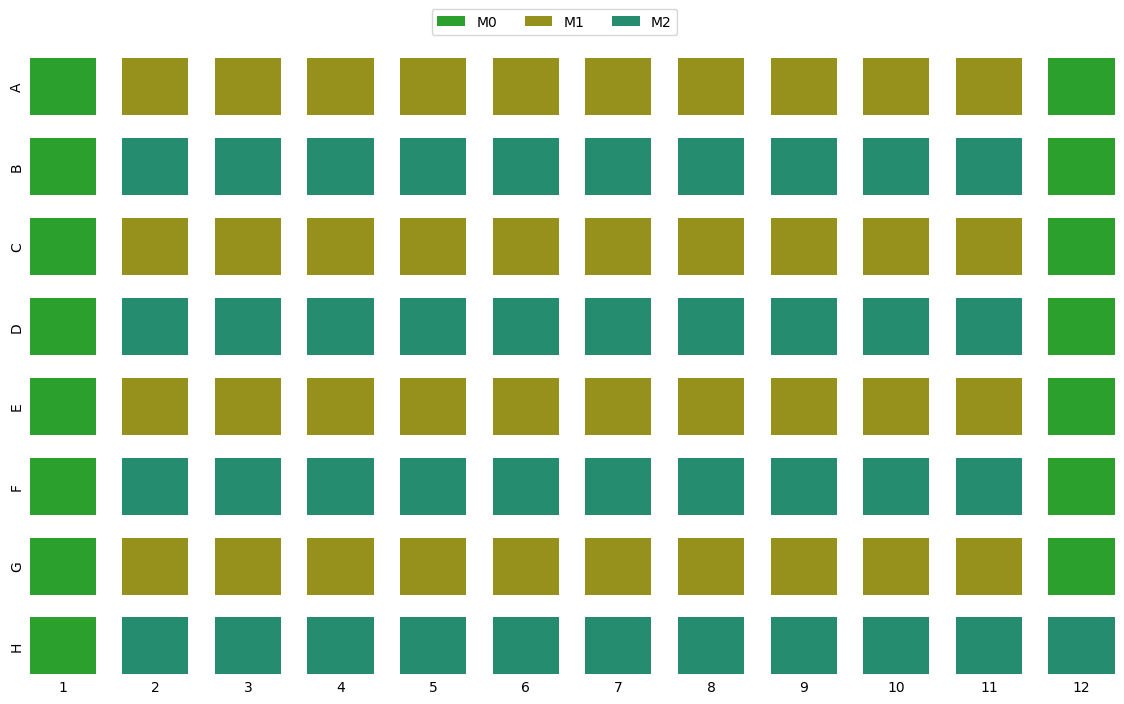

In [76]:
plotHeatmapsFromLayouts(
    params,
    M_all,
    media_cmap,
    title="Media layout",
)

### Bacteria Layout


In [60]:
bacteria_layout_inputs = setup_multiplate_layout_inputs(
    params=params,
    layout_file_key="fileInoculationName",
    num_plates=num_plates,
    same_layout_all_plates=same_bacteria_layout_all_plates,
    nrows=8,
    ncols=12,
    title="Bacteria layout",
)

HTML(value='<b>Bacteria layout | plate 1</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

HTML(value='<b>Bacteria layout | plate 2</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [61]:
B_all = save_multiplate_layout_from_inputs(
    layout_inputs=bacteria_layout_inputs,
    file_path=params["fileInoculationName"],
    num_plates=num_plates,
    same_layout_all_plates=same_bacteria_layout_all_plates,
)

In [62]:
def generate_bacteria_cmap(B_all, empty_key="0", empty_color="lightgray", seed=None):
    """
    Generate a categorical color map for bacteria layout keys.

    Expected structure:
        B_all[plate][row][column]
    """

    rng = random.Random(seed)

    unique_values = sorted(
        set(
            value
            for plate_layout in B_all
            for row in plate_layout
            for value in row
        )
    )

    bacteria_cmap = {}

    for value in unique_values:
        if value == empty_key:
            bacteria_cmap[value] = empty_color
        else:
            random_color = "#{:02x}{:02x}{:02x}".format(
                rng.randint(0, 255),
                rng.randint(0, 255),
                rng.randint(0, 255),
            )
            bacteria_cmap[value] = random_color

    return bacteria_cmap

In [63]:
bacteria_cmap = generate_bacteria_cmap(B_all, seed=1)

for key, color in bacteria_cmap.items():
    print(f"{key}: {color}")

# Compatibility with older plotting/script cells.
inoculation_cmap = bacteria_cmap

0: lightgray
B1: #442082
B2: #3cfde6
B3: #f1c26b
B4: #30f90e
MIX: #c7dd01


In [64]:
bacteria_source_keys = sorted(trough_unique_keys)

print("Bacteria source keys:", bacteria_source_keys)

B_unique_keys, bacteria_key_input_widgets = setup_key_dict_inputs(
    layouts=B_all,
    source_keys=bacteria_source_keys,
    key_dict_file=params["fileBacteriaKeyDictName"],
)

Bacteria source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']


In [65]:
bacteria_key_data = blw.save_key_dict_from_widgets(
    bacteria_key_input_widgets,
    params["fileBacteriaKeyDictName"],
    source_keys=bacteria_source_keys,
)

[{'KEY': 'B1', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 20, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'B2', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 20, 'OV3': 0, 'OV4': 0}, {'KEY': 'B3', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 0, 'OV3': 20, 'OV4': 0}, {'KEY': 'B4', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 20}, {'KEY': 'MIX', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 5, 'OV2': 5, 'OV3': 5, 'OV4': 5}]

> Exporting experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_key_dict.txt




**** BACTERIA LAYOUT | PLATE 1:



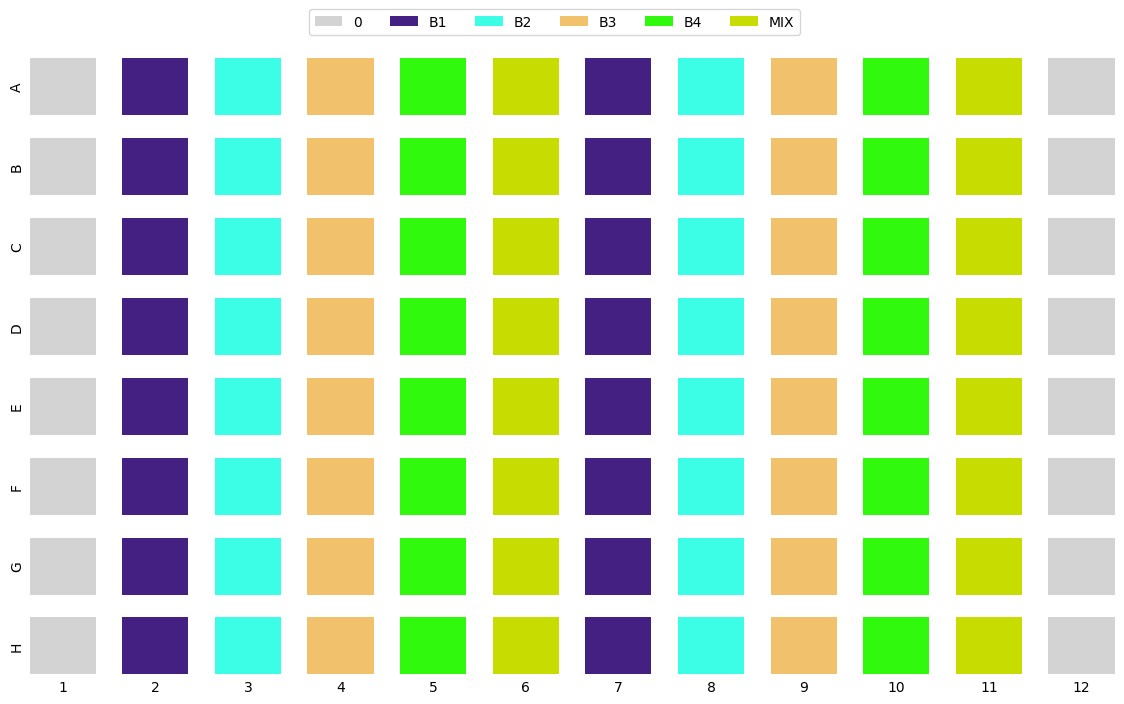



**** BACTERIA LAYOUT | PLATE 2:



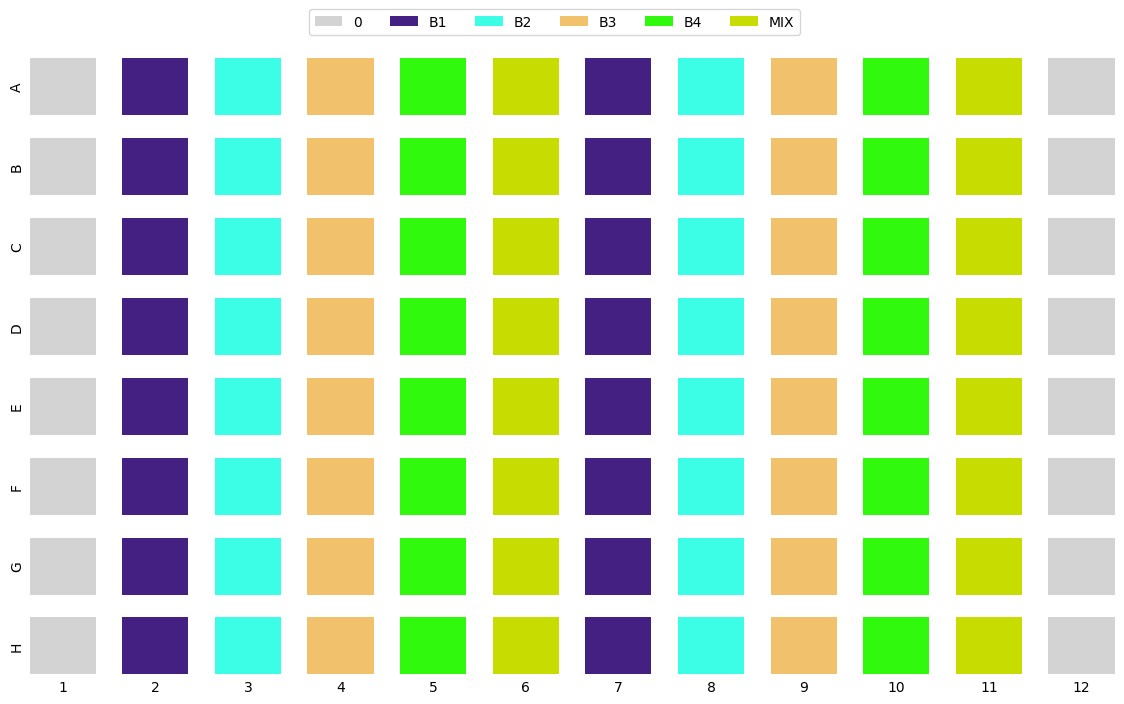

In [66]:
plotHeatmapsFromLayouts(
    params,
    B_all,
    bacteria_cmap,
    title="Bacteria layout",
)